<a href="https://colab.research.google.com/github/Akanshajoshiiii/NLP_LAB/blob/main/token_6_04_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from datasets import load_dataset
dataset = load_dataset("lhoestq/conll2003")

Generating test split: 100%|██████████| 3453/3453 [00:00<00:00, 711132.85 examples/s]


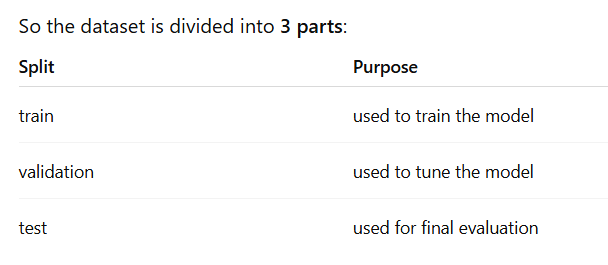

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})

pos_tags
These represent Part of Speech
chunk_tags
These represent syntactic chunks/phrases







In [ ]:
dataset['train'][0]

{'id': '0',
 'tokens': ['EU',
  'rejects',
  'German',
  'call',
  'to',
  'boycott',
  'British',
  'lamb',
  '.'],
 'pos_tags': [22, 42, 16, 21, 35, 37, 16, 21, 7],
 'chunk_tags': [11, 21, 11, 12, 21, 22, 11, 12, 0],
 'ner_tags': [3, 0, 7, 0, 0, 0, 7, 0, 0]}

In [ ]:
#tagnames=dataset['train'].features['ner_tags'].feature.names

In [ ]:
#print(type(dataset['train'].features['ner_tags']))

In [ ]:
#len(tagnames)


Sentences have different lengths.

Example:

Sentence1

EU rejects German call

Sentence2

British lamb

But neural networks require same length inputs.

So we add padding.

Example after padding:

EU rejects German call
British lamb PAD PAD
Problem Without Masking

If we compute loss on PAD tokens:

British lamb PAD PAD

Model will try to predict NER tag for PAD, which is meaningless.

So we mask PAD tokens.

Mask example:

British lamb PAD PAD
1       1    0   0

1 = compute loss
0 = ignore

Masking Token = Padding
Sentence lengths different hote hain.

Sentence1: EU rejects German call
Sentence2: British lamb

Padding ke baad:

EU rejects German call
British lamb <PAD> <PAD>

Agar masking na karo to model PAD tokens pe bhi loss compute karega, jo galat hai.

Counter is a class from Python’s collections module used to count the frequency of elements.
Here we create an empty Counter object named counter.
This will later store how many times each word appears in the training dataset.
Example

If we process these words:

EU
German
EU
British

The counter will store:

EU: 2
German: 1
British: 1
Why We Need It

We use the frequency information to build the vocabulary of the dataset.



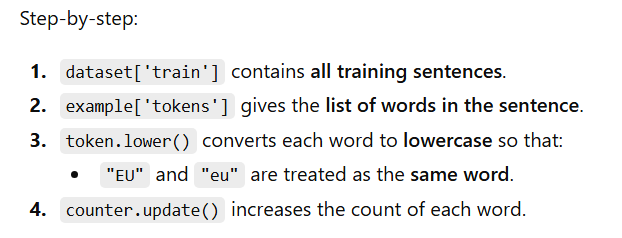

Explanation

Here we create the initial vocabulary dictionary.

Vocabulary means a mapping between words and numbers.

Example format:

word → number

We start by adding two special tokens:

Token	Meaning
PAD	Used for padding sentences
UNK	Used for unknown words

In [ ]:
from collections import Counter
counter=Counter()
#training set se vocabulary learn krte h
for example in dataset['train']:
    counter.update(token.lower() for token in example ['tokens'])
vocab={}
#KUCH ESE WORDS JO TRAIN M ARE BUT TEST M NHI UNKE LIE SPCL TOKEN
vocab={'PAD':0,'UNK':1}
for word in counter:
    #adds all words from the counter into the vocabulary.
    #counter contains all words from training data.
    #For each word, we assign a unique numerical ID.
    #len(vocab) ensures each word gets the next available number.
    vocab[word]=len(vocab)


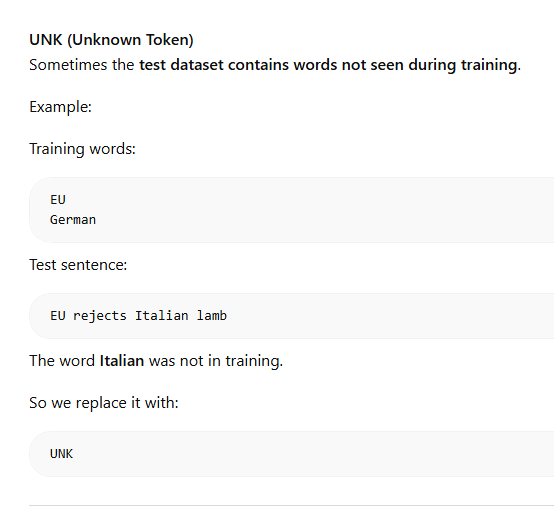

Why This Is Important

Neural networks cannot process text directly.

So we convert words into numbers.

Example sentence:

EU rejects German

Using vocabulary:

[2,3,4]

These numbers are then used as input to the model.

In [ ]:
vocab

{'PAD': 0,
 'UNK': 1,
 'eu': 2,
 'rejects': 3,
 'german': 4,
 'call': 5,
 'to': 6,
 'boycott': 7,
 'british': 8,
 'lamb': 9,
 '.': 10,
 'peter': 11,
 'blackburn': 12,
 'brussels': 13,
 '1996-08-22': 14,
 'the': 15,
 'european': 16,
 'commission': 17,
 'said': 18,
 'on': 19,
 'thursday': 20,
 'it': 21,
 'disagreed': 22,
 'with': 23,
 'advice': 24,
 'consumers': 25,
 'shun': 26,
 'until': 27,
 'scientists': 28,
 'determine': 29,
 'whether': 30,
 'mad': 31,
 'cow': 32,
 'disease': 33,
 'can': 34,
 'be': 35,
 'transmitted': 36,
 'sheep': 37,
 'germany': 38,
 "'s": 39,
 'representative': 40,
 'union': 41,
 'veterinary': 42,
 'committee': 43,
 'werner': 44,
 'zwingmann': 45,
 'wednesday': 46,
 'should': 47,
 'buy': 48,
 'sheepmeat': 49,
 'from': 50,
 'countries': 51,
 'other': 52,
 'than': 53,
 'britain': 54,
 'scientific': 55,
 'was': 56,
 'clearer': 57,
 '"': 58,
 'we': 59,
 'do': 60,
 "n't": 61,
 'support': 62,
 'any': 63,
 'such': 64,
 'recommendation': 65,
 'because': 66,
 'see': 67,
 '

vocab is the dictionary that maps words → numbers (IDs).

In [ ]:
len(vocab)

21011

In [ ]:
def encode(example): #each example is one sentence from dataset
    input_ids = [vocab.get(token.lower(), 1) for token in example['tokens']] #for each word convert to lowercase, find id  from vocab

    return {
        'input_ids': input_ids,
        'labels': example['ner_tags']
    }

return dictionary  
input_ids → word IDs
labels → NER tags

map() applies the encode() function to every sentence.

train → 14041 sentences
validation → 3250
test → 3453

Each sentence now gets two new fields:

input_ids
labels

In [ ]:
dataset=dataset.map(encode)

Map: 100%|██████████| 3453/3453 [00:00<00:00, 5395.16 examples/s] 


In [ ]:
dataset['train'][0]

{'id': '0',
 'tokens': ['EU',
  'rejects',
  'German',
  'call',
  'to',
  'boycott',
  'British',
  'lamb',
  '.'],
 'pos_tags': [22, 42, 16, 21, 35, 37, 16, 21, 7],
 'chunk_tags': [11, 21, 11, 12, 21, 22, 11, 12, 0],
 'ner_tags': [3, 0, 7, 0, 0, 0, 7, 0, 0],
 'input_ids': [2, 3, 4, 5, 6, 7, 8, 9, 10],
 'labels': [3, 0, 7, 0, 0, 0, 7, 0, 0]}

Two approaches
Fixed Padding

Pad everything to 256 tokens.

Example:

Sentence length = 8
→ padded to 256

Wasteful.

Dynamic Padding (better)

Pad to maximum length in batch.

Example batch:

Sentence1 length = 5
Sentence2 length = 7
Sentence3 length = 4

Max length:7

So pad all sentences to length 7.

When DataLoader creates a batch:

batch = [sample1, sample2, sample3 ...]

But sentences have different lengths.

So we need to:

Pad sentences
Pad labels
Create mask

Collate function does this.

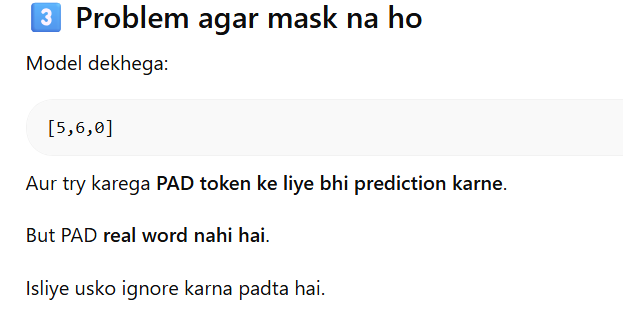

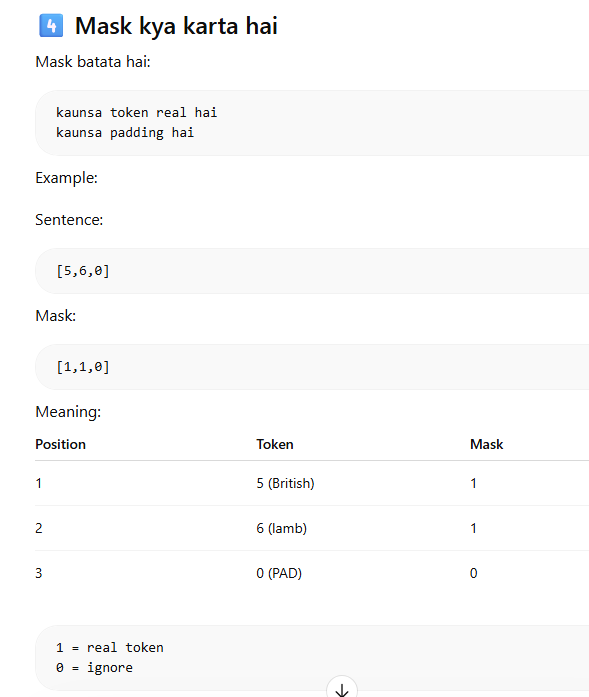

In [ ]:
def collate_fn(batch):
    maxlen=([len(x['input_ids']) for x in batch])
    input_ids=[]
    labels=[]
    mask=[]
    for x in batch:
        L=len(x['input_ids'])
        pad_length=maxlen-L
        input_ids.append(x['input_ids']+[0]*pad_length)
        #jitni pad_len utne 0 add krdo
        #L=sentence len
        labels.append(x['labels']+[0]*pad_length)
        mask.append([1]*L+[0]*pad_length)
        #convert to tensor as neural networks use tensors instead of lists
    return torch.tensor(input_ids),torch.tensor(labels),torch.tensor(mask)


DataLoader:

1️⃣ divides dataset into batches
2️⃣ applies collate function
3️⃣ returns padded tensors

Example batch output shape:

input_ids → (32 , max_len)
labels → (32 , max_len)
mask → (32 , max_len)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset['train'],
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    dataset['test'],
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

Input IDs  
↓
Embedding Layer  
↓
LSTM  (implemented manually)  
↓
Linear Layer  
↓
NER Tag Prediction

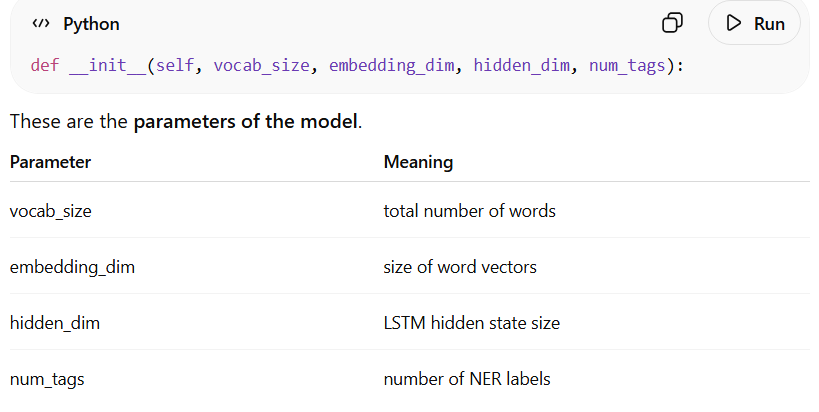

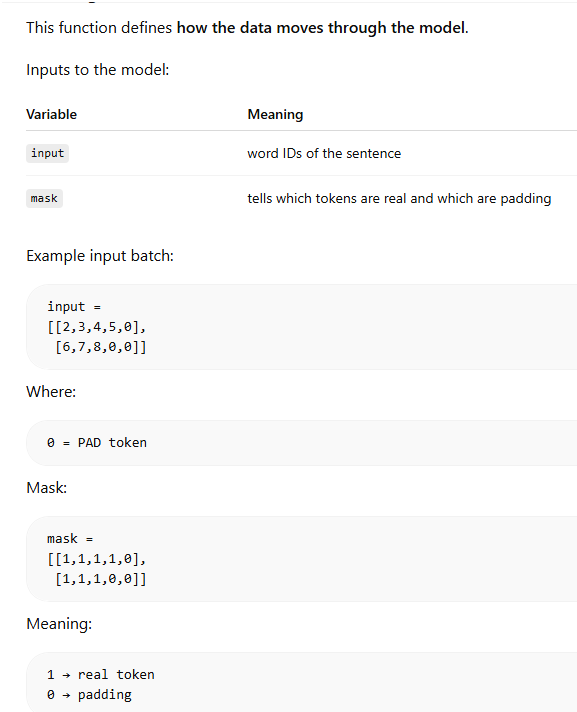

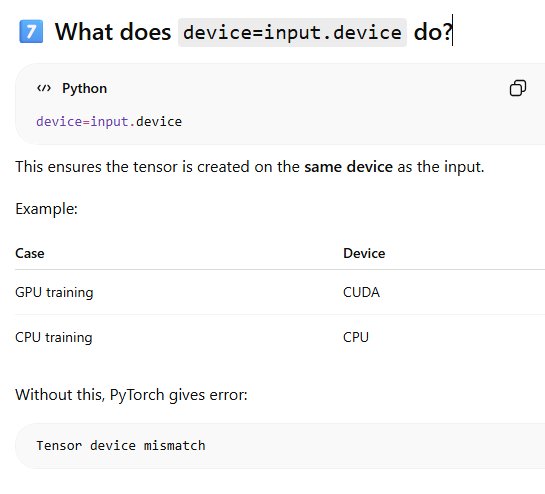

In [ ]:
#scratch LSTM
# embedding layer--lstm--output layer
import torch.nn as nn

class LSTMModel(nn.Module): #this creates a pytorch NN model


    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_tags):
        super(LSTMModel, self).__init__() #parent constructor , Pytorch base class

        self.embedding = nn.Embedding(vocab_size, embedding_dim) #convert word ids to vectors
        self.hidden_dim=hidden_dim

        #input gate
        #i = sigmoid(Wix*xt + Wia*h)
        self.Wix=nn.Linear(embedding_dim, hidden_dim)
        self.Wia=nn.Linear(hidden_dim, hidden_dim)
        #output gate
        self.Wox=nn.Linear(embedding_dim, hidden_dim)
        self.Woa=nn.Linear(hidden_dim, hidden_dim)
        #forget gate
        self.Wfx=nn.Linear(embedding_dim, hidden_dim)
        self.Wfa=nn.Linear(hidden_dim, hidden_dim)
        #candidate gate
        self.Wcx=nn.Linear(embedding_dim, hidden_dim)
        self.Wca=nn.Linear(hidden_dim, hidden_dim)
        #outputlayer
        self.fc=nn.Linear(hidden_dim,num_tags)

    def forward(self,input,mask):
        emb=self.embedding(input) #Word IDs → word vectors.
        # shape becomes :(batch_size , sequence_length , embedding_dim)
        B,T,d=emb.shape
        #h=hidden state of lstm
        #c= cell state (long term memory)
        h=torch.zeros(B,self.hidden_dim,device=input.device)
        #creates a tensor filled with all zeroes
        c=torch.zeros(B,self.hidden_dim,device=input.device)


        for t in range(T): #for each word in sentence
            xt=emb[:,t,:] #take emb of curr word
            #a =torch.cat(xt,h)
            #it​=σ(Wi​xt​+Ui​ht−1​)
            i=torch.sigmoid(self.W_ix(xt)+self.W_ia(h))
            f=torch.sigmoid(self.W_fx(xt)+self.W_fa(h))
            o=torch.sigmoid(self.W_ox(xt)+self.W_oa(h))
            cand=torch.tanh(self.W_cx(xt)+self.W_ca(h))
            #ct​=ft⊙ct−1​+it​⊙c~t​
            c=i*cand+f*c
            h=o*torch.tanh(C)
            h=h*mask[:,t].unsqueeze(1) #if mask 0 , ignore
            c=c*mask[:,t].unsqueeze(1)
            output=self.fc(h)
            #pytorch m cross entropy m hi softmax hota h
            outputs.append(output)











In [ ]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_tags):
        super(LSTMModel, self).__init__()

        # hidden dimension store karna
        self.hidden_dim = hidden_dim

        # word ids -> word vectors
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # input gate
        self.Wix = nn.Linear(embedding_dim, hidden_dim)
        self.Wih = nn.Linear(hidden_dim, hidden_dim)

        # output gate
        self.Wox = nn.Linear(embedding_dim, hidden_dim)
        self.Woh = nn.Linear(hidden_dim, hidden_dim)

        # forget gate
        self.Wfx = nn.Linear(embedding_dim, hidden_dim)
        self.Wfh = nn.Linear(hidden_dim, hidden_dim)

        # candidate state
        self.Wcx = nn.Linear(embedding_dim, hidden_dim)
        self.Wch = nn.Linear(hidden_dim, hidden_dim)

        # final layer (NER tags prediction)
        self.fc = nn.Linear(hidden_dim, num_tags)


    def forward(self, input, mask):

        # input ids -> embeddings
        emb = self.embedding(input)

        # B=batch size, T=seq length, d=embedding dim
        B, T, d = emb.shape

        # initial hidden state
        h = torch.zeros(B, self.hidden_dim, device=input.device)

        # initial cell state
        c = torch.zeros(B, self.hidden_dim, device=input.device)

        outputs = []

        # sequence loop (time steps)
        for t in range(T):

            # current word embedding
            xt = emb[:, t, :]

            # input gate
            i = torch.sigmoid(self.Wix(xt) + self.Wih(h))

            # forget gate
            f = torch.sigmoid(self.Wfx(xt) + self.Wfh(h))

            # output gate
            o = torch.sigmoid(self.Wox(xt) + self.Woh(h))

            # candidate cell state
            cand = torch.tanh(self.Wcx(xt) + self.Wch(h))

            # cell state update
            c = f * c + i * cand

            # hidden state
            h = o * torch.tanh(c)

            # masking (padding tokens ignore karne ke liye)
            h = h * mask[:, t].unsqueeze(1)
            c = c * mask[:, t].unsqueeze(1)

            # tag prediction
            output = self.fc(h)

            outputs.append(output)



        return torch.stack(outputs,dim=1)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = LSTMModel(len(vocab), 128, 128, 9).to(device)

In [ ]:
def masked_loss(otputs,labels,mask):
    b,T,c=outputs.shape
    outputs=outputs.view(B*T,c)
    labels=labels.view(B*T)
    mask=mask.view(B*T)
    loss=torch.nn.functional.cross_entropy(outputs,labels)
    loss=loss*mask
    return loss.sum()/mask.sum()

